In [14]:
import torch , numpy as np, pandas as pd
from fastai.tabular.all import *

In [15]:
df=pd.read_csv(r'C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\titanic_data\titanic_train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [16]:
def add_features(df):
    df['LogFare'] = np.log1p(df['Fare'])
    df['Deck'] = df.Cabin.str[0].map(dict(A="ABC", B="ABC", C="ABC", D="DE", E="DE", F="FG", G="FG"))
    df['Family'] = df.SibSp+df.Parch
    df['Alone'] = df.Family==0
    df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')
    df['Title'] = df.Name.str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
    df['Title'] = df.Title.map(dict(Mr="Mr",Miss="Miss",Mrs="Mrs",Master="Master"))

add_features(df)

In [17]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LogFare,Deck,Family,Alone,TicketFreq,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2.110213,NaN,1,False,1,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593,ABC,1,False,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.188856,NaN,0,True,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834,ABC,1,False,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2.202765,NaN,0,True,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2.639057,NaN,0,True,1,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,3.433987,ABC,0,True,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3.196630,NaN,3,False,2,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,3.433987,ABC,0,True,1,Mr


In [18]:
splits=RandomSplitter(seed=42)(df)

In [19]:
splits[0]

(#713) [788,525,821,253,374,98,215,313,281,305...]

In [20]:
dls=TabularPandas(df,splits=splits,
                  procs=[Categorify,FillMissing,Normalize],
                  cat_names=["Sex","Pclass","Embarked","Deck","Title"],
                  cont_names=['Age','SibSp','Parch','LogFare','Alone','TicketFreq','Family'],
                  y_names="Survived",y_block = CategoryBlock(),
                  ).dataloaders(path=".")

In [21]:
learn=tabular_learner(dls,metrics=accuracy,layers=[10,10])

SuggestedLRs(slide=0.10000000149011612, valley=0.007585775572806597)

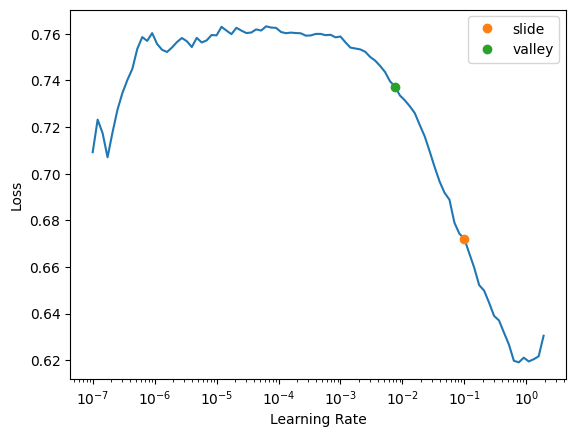

In [22]:
learn.lr_find(suggest_funcs=(slide,valley))

In [13]:
learn.fit(16,lr=0.03)

epoch,train_loss,valid_loss,accuracy,time
0,0.313272,0.554089,0.803371,00:00
1,0.297567,0.571920,0.792135,00:00
2,0.297731,0.600846,0.797753,00:00
3,0.293962,0.583766,0.792135,00:00
4,0.293068,0.564136,0.780899,00:00
5,0.297335,0.578016,0.786517,00:00
6,0.290526,0.568554,0.808989,00:00
7,0.294046,0.574219,0.786517,00:00
8,0.290791,0.578602,0.797753,00:00
9,0.291314,0.583125,0.792135,00:00


## Submit to Kaggle 

In [24]:

tst_df=pd.read_csv(r'C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\titanic_data\titanic_test.csv')
tst_df['Fare']= tst_df.Fare.fillna(0)
add_features(tst_df)

In [25]:
tst_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LogFare,Deck,Family,Alone,TicketFreq,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,2.178064,NaN,0,True,1,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2.079442,NaN,1,False,1,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,2.369075,NaN,0,True,1,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,2.268252,NaN,0,True,1,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,2.586824,NaN,2,False,1,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,2.202765,NaN,0,True,1,Mr
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,4.699571,ABC,0,True,1,NaN
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,2.110213,NaN,0,True,1,Mr
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,2.202765,NaN,0,True,1,Mr


In [26]:
tst_dl=learn.dls.test_dl(tst_df)

In [55]:
preds,_=learn.get_preds(dl=tst_dl)

In [67]:
preds

tensor([[0.4923, 0.5077],
        [0.5079, 0.4921],
        [0.5125, 0.4875],
        [0.4885, 0.5115],
        [0.4986, 0.5014],
        [0.4891, 0.5109],
        [0.4896, 0.5104],
        [0.4973, 0.5027],
        [0.4880, 0.5120],
        [0.5041, 0.4959],
        [0.4890, 0.5110],
        [0.4958, 0.5042],
        [0.4995, 0.5005],
        [0.5097, 0.4903],
        [0.4975, 0.5025],
        [0.4969, 0.5031],
        [0.4894, 0.5106],
        [0.4880, 0.5120],
        [0.4993, 0.5007],
        [0.4993, 0.5007],
        [0.4985, 0.5015],
        [0.4969, 0.5031],
        [0.4979, 0.5021],
        [0.4907, 0.5093],
        [0.5342, 0.4658],
        [0.5014, 0.4986],
        [0.4905, 0.5095],
        [0.4881, 0.5119],
        [0.4943, 0.5057],
        [0.5011, 0.4989],
        [0.4964, 0.5036],
        [0.5008, 0.4992],
        [0.5182, 0.4818],
        [0.5131, 0.4869],
        [0.4968, 0.5032],
        [0.4882, 0.5118],
        [0.4890, 0.5110],
        [0.4881, 0.5119],
        [0.4

In [73]:
(preds[:,1]>0.5).int()

tensor([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [74]:
tst_df['Survived']=(preds[:,1]>0.5).int()

In [76]:
sub_df=tst_df[['PassengerId','Survived']]

In [77]:
sub_df

,PassengerId,Survived
0,892,1
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,1
414,1306,0
415,1307,1
416,1308,1


In [78]:
sub_df.to_csv('sub.csv',index=False)

In [61]:
preds[:,1]

tensor([0.5077, 0.4921, 0.4875, 0.5115, 0.5014, 0.5109, 0.5104, 0.5027, 0.5120,
        0.4959, 0.5110, 0.5042, 0.5005, 0.4903, 0.5025, 0.5031, 0.5106, 0.5120,
        0.5007, 0.5007, 0.5015, 0.5031, 0.5021, 0.5093, 0.4658, 0.4986, 0.5095,
        0.5119, 0.5057, 0.4989, 0.5036, 0.4992, 0.4818, 0.4869, 0.5032, 0.5118,
        0.5110, 0.5119, 0.5119, 0.4996, 0.4969, 0.5041, 0.5038, 0.5110, 0.5031,
        0.5117, 0.5057, 0.5109, 0.5000, 0.4853, 0.5020, 0.5098, 0.4946, 0.4932,
        0.5095, 0.4801, 0.5075, 0.5115, 0.5020, 0.4850, 0.5115, 0.5105, 0.5117,
        0.5121, 0.4986, 0.5063, 0.5118, 0.5042, 0.5044, 0.4618, 0.5118, 0.5118,
        0.5107, 0.5038, 0.4901, 0.4896, 0.5110, 0.4957, 0.5109, 0.5118, 0.5029,
        0.4935, 0.5018, 0.5110, 0.5116, 0.5034, 0.5112, 0.5118, 0.5110, 0.5043,
        0.5030, 0.5109, 0.4982, 0.5110, 0.5030, 0.5116, 0.4939, 0.5107, 0.5120,
        0.5089, 0.5028, 0.5031, 0.5109, 0.5114, 0.5011, 0.5056, 0.5118, 0.5109,
        0.5113, 0.5101, 0.5070, 0.5109, 

In [79]:
!head sub.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


# Ensembling



In [80]:
def ensemble():
    learn=tabular_learner(dls,metrics=accuracy,layers=[10,10])
    with learn.no_bar(),learn.no_logging():learn.fit(17,lr=0.03)
    return learn.get_preds(dl=tst_dl)[0]

In [81]:
learns= [ensemble() for _ in range(5)]

In [89]:
learns


[tensor([[0.9164, 0.0836],
         [0.5280, 0.4720],
         [0.9383, 0.0617],
         [0.8659, 0.1341],
         [0.4282, 0.5718],
         [0.9055, 0.0945],
         [0.4080, 0.5920],
         [0.8403, 0.1597],
         [0.2124, 0.7876],
         [0.8668, 0.1332],
         [0.9315, 0.0685],
         [0.9258, 0.0742],
         [0.0335, 0.9665],
         [0.9352, 0.0648],
         [0.0306, 0.9694],
         [0.0267, 0.9733],
         [0.9051, 0.0949],
         [0.6551, 0.3449],
         [0.5231, 0.4769],
         [0.3981, 0.6019],
         [0.9081, 0.0919],
         [0.3221, 0.6779],
         [0.0721, 0.9279],
         [0.8057, 0.1943],
         [0.0437, 0.9563],
         [0.9258, 0.0742],
         [0.0343, 0.9657],
         [0.6654, 0.3346],
         [0.8253, 0.1747],
         [0.8716, 0.1284],
         [0.9354, 0.0646],
         [0.9314, 0.0686],
         [0.4801, 0.5199],
         [0.4478, 0.5522],
         [0.4591, 0.5409],
         [0.6571, 0.3429],
         [0.5625, 0.4375],
 

In [100]:
learns

[tensor([[0.9164, 0.0836],
         [0.5280, 0.4720],
         [0.9383, 0.0617],
         [0.8659, 0.1341],
         [0.4282, 0.5718],
         [0.9055, 0.0945],
         [0.4080, 0.5920],
         [0.8403, 0.1597],
         [0.2124, 0.7876],
         [0.8668, 0.1332],
         [0.9315, 0.0685],
         [0.9258, 0.0742],
         [0.0335, 0.9665],
         [0.9352, 0.0648],
         [0.0306, 0.9694],
         [0.0267, 0.9733],
         [0.9051, 0.0949],
         [0.6551, 0.3449],
         [0.5231, 0.4769],
         [0.3981, 0.6019],
         [0.9081, 0.0919],
         [0.3221, 0.6779],
         [0.0721, 0.9279],
         [0.8057, 0.1943],
         [0.0437, 0.9563],
         [0.9258, 0.0742],
         [0.0343, 0.9657],
         [0.6654, 0.3346],
         [0.8253, 0.1747],
         [0.8716, 0.1284],
         [0.9354, 0.0646],
         [0.9314, 0.0686],
         [0.4801, 0.5199],
         [0.4478, 0.5522],
         [0.4591, 0.5409],
         [0.6571, 0.3429],
         [0.5625, 0.4375],
 

In [103]:
ens_preds=torch.stack(learns).mean(0)

In [104]:
ens_preds

tensor([[0.9121, 0.0879],
        [0.6044, 0.3956],
        [0.9625, 0.0375],
        [0.8712, 0.1288],
        [0.3461, 0.6539],
        [0.8490, 0.1510],
        [0.4227, 0.5773],
        [0.9207, 0.0793],
        [0.2032, 0.7968],
        [0.8788, 0.1212],
        [0.9320, 0.0680],
        [0.8708, 0.1292],
        [0.0201, 0.9799],
        [0.9516, 0.0484],
        [0.0261, 0.9739],
        [0.0160, 0.9840],
        [0.9160, 0.0840],
        [0.6964, 0.3036],
        [0.5795, 0.4205],
        [0.5364, 0.4636],
        [0.8742, 0.1258],
        [0.1589, 0.8411],
        [0.0597, 0.9403],
        [0.7757, 0.2243],
        [0.0528, 0.9472],
        [0.9398, 0.0602],
        [0.0202, 0.9798],
        [0.7087, 0.2913],
        [0.7752, 0.2248],
        [0.8744, 0.1256],
        [0.9363, 0.0637],
        [0.9413, 0.0587],
        [0.4081, 0.5919],
        [0.4241, 0.5759],
        [0.5024, 0.4976],
        [0.6862, 0.3138],
        [0.6153, 0.3847],
        [0.4960, 0.5040],
        [0.8

In [ ]:
tst_df['Survived']=(ens_preds[:,1]>0.5).int()
sub_df=tst_df[['PassengerId','Survived']]
sub_df.to_csv('ens_sub.csv',index=False)